# Tests Statistiques : Box-Muller
Vérification de la distribution normale (gaussienne) générée par la transformée.

In [10]:
import sys
import os
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))
from generators.box_muller import box_muller

In [11]:
data_bm = []
for _ in range(25000):
    z0, z1 = box_muller()
    data_bm.extend([z0, z1])

# Tests
autocorr_1 = np.corrcoef(np.array(data_bm)[:-1], np.array(data_bm)[1:])[0, 1]
print(f"AutoCorr (lag 1) : {autocorr_1:.4f} (Idéal: ~0)")

autocorr_8 = np.corrcoef(np.array(data_bm)[:-8], np.array(data_bm)[8:])[0, 1]
print(f"AutoCorr (lag 8) : {autocorr_8:.4f} (Idéal: ~0)")
ks_stat, p_value = stats.kstest(data_bm, 'norm')
print(f"Test KS (Normal) : p-value = {p_value:.4f} (>0.05 = suit une loi normale)")



AutoCorr (lag 1) : 0.0019 (Idéal: ~0)
AutoCorr (lag 8) : 0.0078 (Idéal: ~0)
Test KS (Normal) : p-value = 0.9637 (>0.05 = suit une loi normale)


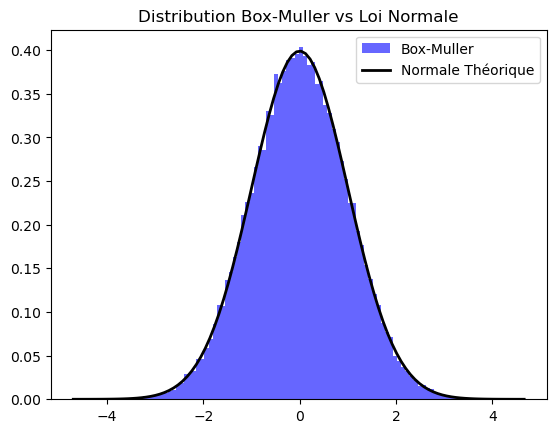

In [12]:
plt.hist(data_bm, bins=100, density=True, alpha=0.6, color='blue', label="Box-Muller")
xmin, xmax = plt.xlim()
x_axis = np.linspace(xmin, xmax, 100)
plt.plot(x_axis, stats.norm.pdf(x_axis, 0, 1), 'k', linewidth=2, label="Normale Théorique")
plt.title("Distribution Box-Muller vs Loi Normale")
plt.legend()
plt.show()

**Remarque :**
Contrairement aux générateurs de flux de bits/octets (LCG, BBS), la transformée de Box-Muller génère des variables continues suivant une loi Normale. 
C'est pourquoi nous n'appliquons pas l'Entropie de Shannon par octet ni le test du $\chi^2$ (destinés à tester l'uniformité discrète). L'évaluation pertinente repose ici sur l'autocorrélation et le test de Kolmogorov-Smirnov adapté à une distribution normale.